# Standalone Heads — MLP & Flow-Based Neural Networks

This notebook demonstrates how to use the **standalone head** estimators from the Mother package:

| Estimator | Task | Key Feature |
|---|---|---|
| `MLPHeadRegressor` | Regression | MC-Dropout uncertainty, multi-target |
| `MLPHeadClassifier` | Classification | Predict-proba, entropy-based uncertainty |
| `FlowHeadRegressor` | Probabilistic Regression | Full predictive distributions via normalizing flows |

These estimators are **sklearn-compatible** (fit / predict / get_params / set_params / pickle)
and wrap PyTorch modules through [skorch](https://skorch.readthedocs.io/).

### Table of Contents

| # | Section |
|---|---|
| 1 | Setup — imports & helpers |
| 2 | MLP Regression |
| 3 | MLP Multi-Target Regression |
| 4 | MLP Uncertainty via MC Dropout |
| 5 | MLP Classification |
| 6 | Classification Probabilities & Uncertainty |
| 7 | Flow-Based Regression (NICE) |
| 8 | Sampling from the Learned Distribution |
| 9 | Flow Uncertainty Quantification |
| 10 | Comparing Flow Architectures |
| 11 | Model Serialization (Pickle) |

## Architecture Overview

### MLP Head

```
Input (n_features)
  │
  ▼
┌────────────────────────┐
│  Linear → BN → Act → Drop  │  × len(hidden_dims)
└────────────────────────┘
  │
  ▼
Linear → output_dim
```

- **Activation**: ReLU (default), GELU, or LeakyReLU
- **Uncertainty**: MC Dropout — run multiple stochastic forward passes at test time

### Flow Head

```
Input (n_features)  ──context──►  Conditional Normalizing Flow
                                       │
                                       ▼
                                  p(y | x)  ← learned distribution
                                       │
                                  ┌────┴────┐
                                  │ .sample()│  → regression samples
                                  │.log_prob()│ → uncertainty (NLL)
                                  └─────────┘
```

Supported flow types: `GMM`, `NICE`, `RealNVP`, `NAF`, `UNAF`, `NSF`, `BPF`

## 1  Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from mother.ml.models.m_heads import (
    MLPHeadRegressor,
    MLPHeadClassifier,
    FlowHeadRegressor,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅ Imports OK")

✅ Imports OK


### Helper — synthetic datasets

In [2]:
def get_regression_data(n=400, n_features=10):
    """Create a simple regression dataset."""
    X, y = make_regression(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        noise=10,
        random_state=RANDOM_STATE,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    # Standardise targets (important for flow heads)
    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.float32),
        y_test.astype(np.float32),
        y_scaler,
    )


def get_multitarget_regression_data(n=400, n_features=10, n_targets=3):
    """Multi-target regression dataset."""
    X, y = make_regression(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        n_targets=n_targets,
        noise=10,
        random_state=RANDOM_STATE,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(y_train)
    y_test = y_scaler.transform(y_test)
    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.float32),
        y_test.astype(np.float32),
        y_scaler,
    )


def get_classification_data(n=400, n_features=10, n_classes=2, weights=None):
    """Create a classification dataset."""
    X, y = make_classification(
        n_samples=n,
        n_features=n_features,
        n_informative=6,
        n_redundant=2,
        n_classes=n_classes,
        random_state=RANDOM_STATE,
        weights=weights,
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    return X_train.astype(np.float32), X_test.astype(np.float32), y_train, y_test


# Quick sanity check
X_tr, X_te, y_tr, y_te, _ = get_regression_data()
print(f"Regression:      X_train {X_tr.shape}, y_train {y_tr.shape}")
X_tr_m, X_te_m, y_tr_m, y_te_m, _ = get_multitarget_regression_data()
print(f"Multi-target:    X_train {X_tr_m.shape}, y_train {y_tr_m.shape}")
X_tr_c, X_te_c, y_tr_c, y_te_c = get_classification_data()
print(f"Classification:  X_train {X_tr_c.shape}, y_train {y_tr_c.shape}")

Regression:      X_train (320, 10), y_train (320,)
Multi-target:    X_train (320, 10), y_train (320, 3)
Classification:  X_train (320, 10), y_train (320,)


---

## 2  MLP Regression

The `MLPHeadRegressor` is a fully-connected neural network wrapped for sklearn compatibility.
It auto-detects `input_dim` and `output_dim` from the training data.

| Parameter | Default | Description |
|---|---|---|
| `hidden_dims` | `[256, 128, 64]` | Hidden layer sizes |
| `dropout` | `0.05` | Dropout rate |
| `activation` | `"ReLU"` | `"ReLU"`, `"GELU"`, `"LeakyReLU"` |
| `batch_norm` | `True` | BatchNorm between layers |
| `max_epochs` | `500` | Training epochs (early stopping active) |
| `lr` | `0.005` | Learning rate (AdamW) |

In [3]:
# Prepare data
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

# Create & fit the regressor
mlp_reg = MLPHeadRegressor(
    hidden_dims=[128, 64],
    dropout=0.1,
    activation="ReLU",
    max_epochs=50,
    lr=0.005,
    verbose=0,
)
mlp_reg.fit(X_train, y_train)

# Evaluate
y_pred = mlp_reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"MLP Regressor  →  R² = {r2:.4f}   RMSE = {rmse:.4f}")

MLP Regressor  →  R² = 0.9708   RMSE = 0.1488


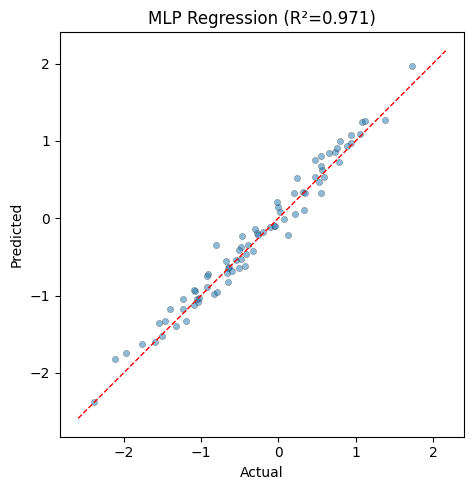

In [4]:
# Parity plot: predicted vs actual
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, edgecolors="k", linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()) - 0.2, max(y_test.max(), y_pred.max()) + 0.2]
ax.plot(lims, lims, "--r", linewidth=1)
ax.set(xlabel="Actual", ylabel="Predicted", title=f"MLP Regression (R²={r2:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---

## 3  MLP Multi-Target Regression

The MLP head natively supports **multi-target** regression. The `output_dim` is automatically
inferred from the shape of `y` during `fit()`.

In [5]:
X_train_m, X_test_m, y_train_m, y_test_m, _ = get_multitarget_regression_data(n_targets=3)
print(f"y_train shape: {y_train_m.shape}  (3 targets)")

mlp_mt = MLPHeadRegressor(
    hidden_dims=[128, 64],
    max_epochs=50,
    lr=0.005,
    verbose=0,
)
mlp_mt.fit(X_train_m, y_train_m)

y_pred_m = mlp_mt.predict(X_test_m)
print(f"Predictions shape: {y_pred_m.shape}")

for t in range(y_train_m.shape[1]):
    r2_t = r2_score(y_test_m[:, t], y_pred_m[:, t])
    print(f"  Target {t}: R² = {r2_t:.4f}")

y_train shape: (320, 3)  (3 targets)
Predictions shape: (80, 3)
  Target 0: R² = 0.9579
  Target 1: R² = 0.9657
  Target 2: R² = 0.9638


---

## 4  MLP Uncertainty via MC Dropout

At test time, dropout layers are kept **active** and we run $N$ stochastic forward passes.
The standard deviation across passes is used as **knowledge (epistemic) uncertainty**:

$$\hat{y} = \frac{1}{N}\sum_{i=1}^{N} f_{\theta_i}(x) \qquad \sigma_{\text{MC}} = \text{std}\left(\{f_{\theta_i}(x)\}_{i=1}^{N}\right)$$

Higher dropout rates produce wider uncertainty bands.

In [6]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

# Use a higher dropout for more visible uncertainty
mlp_unc = MLPHeadRegressor(
    hidden_dims=[128, 64],
    dropout=0.2,
    max_epochs=50,
    lr=0.005,
    verbose=0,
)
mlp_unc.fit(X_train, y_train)

# predict_uncertainty requires a DataFrame
unc_df = mlp_unc.predict_uncertainty(pd.DataFrame(X_test), n_samples=50)
print(unc_df.head(10))
print(f"\nColumns: {list(unc_df.columns)}")

   mean_predictions  knowledge_uncertainty data_uncertainty total_uncertainty
0          0.170015               0.267071             None              None
1         -0.583915               0.225865             None              None
2          0.779526               0.251062             None              None
3          1.384829               0.219601             None              None
4          0.421074               0.278503             None              None
5          0.107464               0.269215             None              None
6          0.729717               0.175363             None              None
7         -0.171437               0.184004             None              None
8          0.017380               0.231441             None              None
9         -0.409724               0.223219             None              None

Columns: ['mean_predictions', 'knowledge_uncertainty', 'data_uncertainty', 'total_uncertainty']


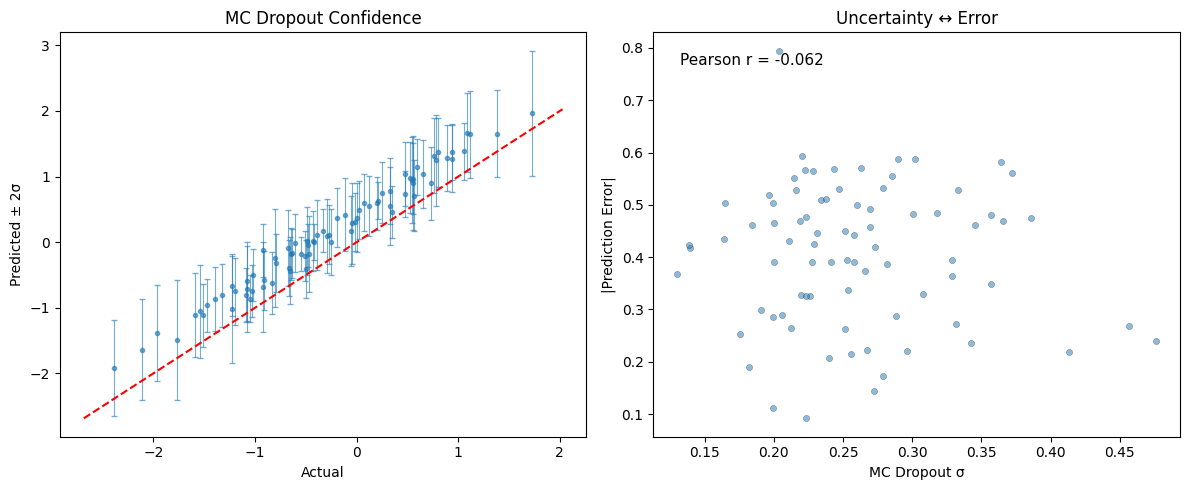

In [7]:
# Visualise uncertainty vs prediction error
means = unc_df["mean_predictions"].values
sigmas = unc_df["knowledge_uncertainty"].values
errors = np.abs(y_test - means)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: parity plot with error bars
order = np.argsort(y_test)
axes[0].errorbar(
    y_test[order],
    means[order],
    yerr=2 * sigmas[order],
    fmt="o",
    ms=3,
    alpha=0.6,
    elinewidth=0.8,
    capsize=2,
)
lims = [y_test.min() - 0.3, y_test.max() + 0.3]
axes[0].plot(lims, lims, "--r")
axes[0].set(xlabel="Actual", ylabel="Predicted ± 2σ", title="MC Dropout Confidence")

# Right: uncertainty vs absolute error (should be correlated)
axes[1].scatter(sigmas, errors, alpha=0.5, s=20, edgecolors="k", linewidths=0.3)
axes[1].set(xlabel="MC Dropout σ", ylabel="|Prediction Error|", title="Uncertainty ↔ Error")

# Add correlation
corr = np.corrcoef(sigmas, errors)[0, 1]
axes[1].annotate(f"Pearson r = {corr:.3f}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=11, va="top")

plt.tight_layout()
plt.show()

---

## 5  MLP Classification

The `MLPHeadClassifier` uses the same MLP architecture with a **CrossEntropyLoss** criterion.
It supports both binary and multi-class classification.

In [8]:
# Binary classification
X_train_c, X_test_c, y_train_c, y_test_c = get_classification_data(n_classes=2)

mlp_clf = MLPHeadClassifier(
    hidden_dims=[128, 64],
    dropout=0.1,
    max_epochs=50,
    lr=0.005,
    verbose=0,
)
mlp_clf.fit(X_train_c, y_train_c)

y_pred_c = mlp_clf.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Binary Classification Accuracy: {acc:.4f}")

Binary Classification Accuracy: 0.9000


In [9]:
# Multi-class classification (4 classes)
X_train_mc, X_test_mc, y_train_mc, y_test_mc = get_classification_data(
    n_features=15,
    n_classes=4,
)

mlp_mc = MLPHeadClassifier(
    hidden_dims=[128, 64],
    max_epochs=50,
    lr=0.005,
    verbose=0,
)
mlp_mc.fit(X_train_mc, y_train_mc)

y_pred_mc = mlp_mc.predict(X_test_mc)
acc_mc = accuracy_score(y_test_mc, y_pred_mc)
print(f"4-Class Accuracy: {acc_mc:.4f}")

4-Class Accuracy: 0.7750


---

## 6  Classification Probabilities & Uncertainty

- **`predict_proba(X)`** returns softmax probabilities for each class.
- **`predict_uncertainty(X)`** uses MC Dropout to estimate **entropy-based** knowledge uncertainty:

$$H = -\sum_{c} \bar{p}_c \log \bar{p}_c \qquad \text{where } \bar{p}_c = \frac{1}{N}\sum_{i=1}^{N} p_c^{(i)}$$

In [10]:
# Predicted probabilities
proba = mlp_clf.predict_proba(X_test_c)
print(f"Probabilities shape: {proba.shape}")
print(f"First 5 rows (sum should ≈ 1):\n{proba[:5]}")
print(f"Row sums: {proba[:5].sum(axis=1)}")

Probabilities shape: (80, 2)
First 5 rows (sum should ≈ 1):
[[9.9951732e-01 4.8264221e-04]
 [9.9997246e-01 2.7534430e-05]
 [9.9877387e-01 1.2260531e-03]
 [9.9989676e-01 1.0317056e-04]
 [9.9840814e-01 1.5918495e-03]]
Row sums: [0.99999994 1.         0.99999994 0.99999994 1.        ]


In [11]:
# Classification uncertainty via MC Dropout
clf_unc = MLPHeadClassifier(
    hidden_dims=[128, 64],
    dropout=0.2,  # higher dropout → more visible uncertainty
    max_epochs=50,
    lr=0.005,
    verbose=0,
)
clf_unc.fit(X_train_c, y_train_c)

unc_clf_df = clf_unc.predict_uncertainty(pd.DataFrame(X_test_c), n_samples=50)
print(unc_clf_df.head(10))

   mean_predictions  knowledge_uncertainty data_uncertainty total_uncertainty
0                 0               0.020543             None              None
1                 0               0.069324             None              None
2                 0               0.453975             None              None
3                 0               0.002457             None              None
4                 0               0.078043             None              None
5                 1               0.006624             None              None
6                 0               0.334981             None              None
7                 1               0.016573             None              None
8                 1               0.015730             None              None
9                 0               0.113295             None              None


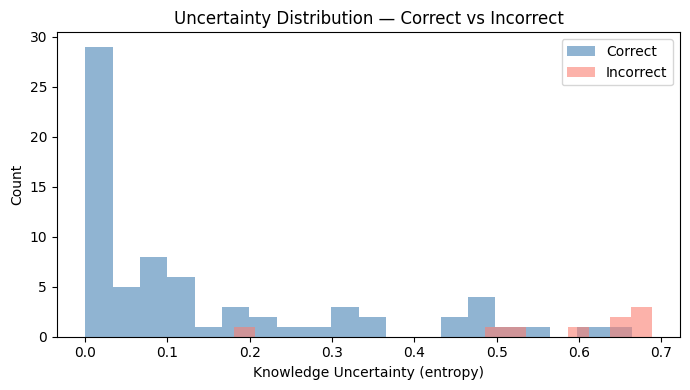

In [12]:
# Visualise: high-uncertainty samples are more likely to be misclassified
preds_unc = unc_clf_df["mean_predictions"].values.astype(int)
correct = preds_unc == y_test_c
entropy = unc_clf_df["knowledge_uncertainty"].values

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(entropy[correct], bins=20, alpha=0.6, label="Correct", color="steelblue")
ax.hist(entropy[~correct], bins=20, alpha=0.6, label="Incorrect", color="salmon")
ax.set(
    xlabel="Knowledge Uncertainty (entropy)", ylabel="Count", title="Uncertainty Distribution — Correct vs Incorrect"
)
ax.legend()
plt.tight_layout()
plt.show()

---

## 7  Flow-Based Regression (NICE)

The `FlowHeadRegressor` learns a **conditional normalizing flow** $p(y \mid x)$.
Instead of predicting a single value, it models the full predictive distribution.

| Parameter | Default | Description |
|---|---|---|
| `flow_type` | `"NICE"` | Architecture: GMM, NICE, RealNVP, NAF, UNAF, NSF, BPF |
| `flow_transforms` | `3` | Number of coupling/autoregressive layers |
| `max_epochs` | `100` | Training epochs |
| `lr` | `0.001` | Learning rate |

The loss is the **negative log-likelihood** of the training targets under the learned distribution.

In [13]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

flow_reg = FlowHeadRegressor(
    flow_type="NICE",
    flow_transforms=3,
    max_epochs=80,
    lr=0.001,
    verbose=0,
)
flow_reg.fit(X_train, y_train)

# Point prediction: MAP estimate from sampled distribution
y_pred_flow = flow_reg.predict(X_test, num_samples=200)
r2_flow = r2_score(y_test, y_pred_flow)
rmse_flow = mean_squared_error(y_test, y_pred_flow, squared=False)
print(f"Flow Regressor (NICE)  →  R² = {r2_flow:.4f}   RMSE = {rmse_flow:.4f}")

Flow Regressor (NICE)  →  R² = 0.9830   RMSE = 0.1135


---

## 8  Sampling from the Learned Distribution

Use `predict_flow(X, num_samples=N)` to draw $N$ samples from $p(y \mid x)$ for each input.
This gives you the **full predictive distribution** rather than just a point estimate.

In [14]:
# Draw samples from the learned distribution
flow_samples = flow_reg.predict_flow(X_test, num_samples=500)
print(f"Flow samples shape: {flow_samples.shape}")  # (n_test, 500, 1)

Flow samples shape: (80, 500, 1)


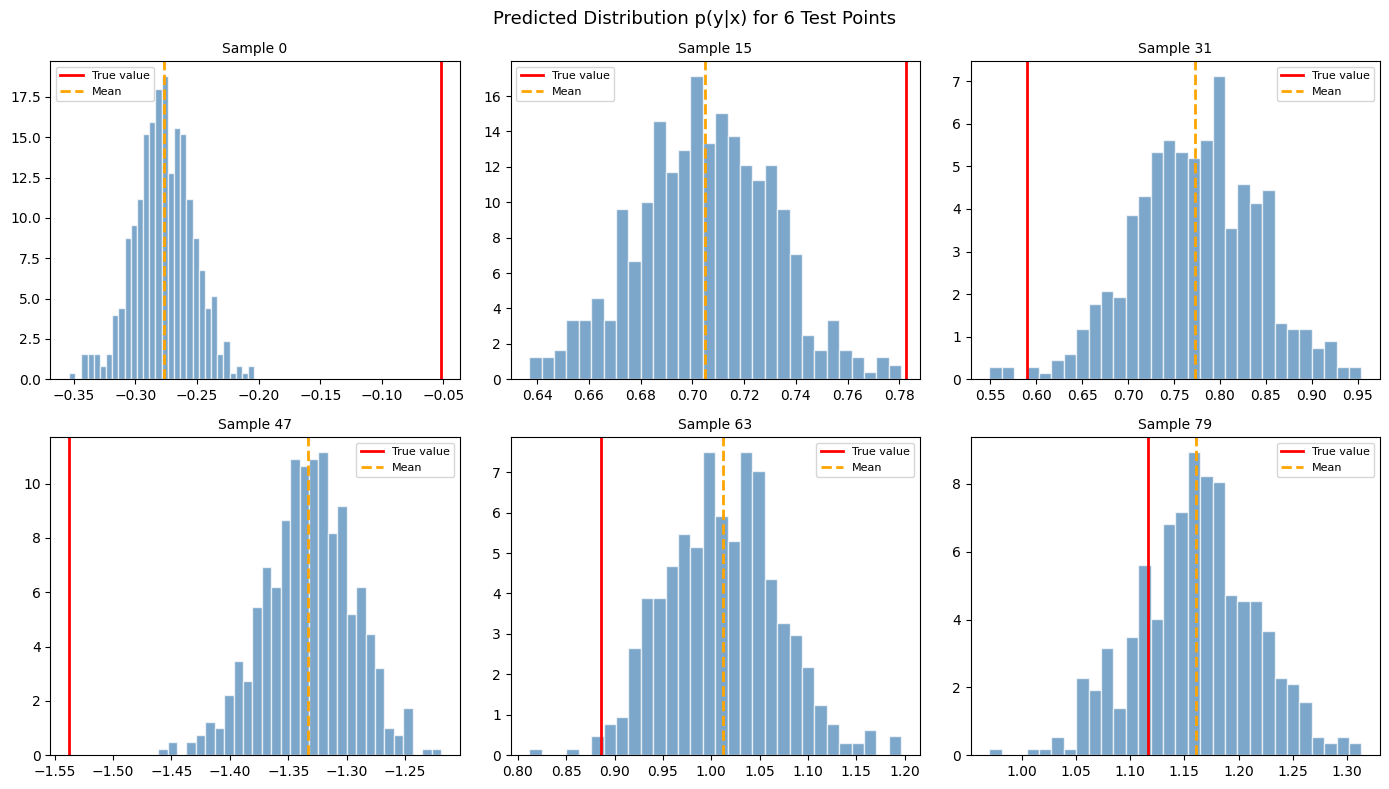

In [15]:
# Visualise the predictive distribution for a few test samples
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
indices = np.linspace(0, len(X_test) - 1, 6, dtype=int)

for ax, idx in zip(axes.ravel(), indices):
    samples_i = flow_samples[idx, :, 0]  # 500 samples for this input
    ax.hist(samples_i, bins=30, density=True, alpha=0.7, color="steelblue", edgecolor="white")
    ax.axvline(y_test[idx], color="red", linewidth=2, label="True value")
    ax.axvline(np.mean(samples_i), color="orange", linewidth=2, linestyle="--", label="Mean")
    ax.set_title(f"Sample {idx}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Predicted Distribution p(y|x) for 6 Test Points", fontsize=13)
plt.tight_layout()
plt.show()

---

## 9  Flow Uncertainty Quantification

`predict_uncertainty()` returns **data (aleatoric) uncertainty** based on the negative
log-probability of the mode under the learned distribution:

$$u_{\text{data}} = -\log p(\hat{y}_{\text{mode}} \mid x)$$

Higher NLL → the model's distribution is wider or less peaked → higher uncertainty.

In [16]:
flow_unc = flow_reg.predict_uncertainty(pd.DataFrame(X_test), num_samples=500)
print(flow_unc.head(10))
print(f"\nColumns: {list(flow_unc.columns)}")

   mean_predictions knowledge_uncertainty  data_uncertainty  total_uncertainty
0         -0.277469                  None         -2.807956          -2.807956
1         -0.771788                  None         -2.624992          -2.624992
2          0.210908                  None         -2.055436          -2.055436
3          1.095740                  None         -1.740205          -1.740205
4         -0.082363                  None         -2.344421          -2.344421
5         -0.256468                  None         -2.436651          -2.436651
6          0.298493                  None         -2.246668          -2.246668
7         -0.538049                  None         -2.003841          -2.003841
8         -0.384350                  None         -1.852659          -1.852659
9         -0.690966                  None         -1.789907          -1.789907

Columns: ['mean_predictions', 'knowledge_uncertainty', 'data_uncertainty', 'total_uncertainty']


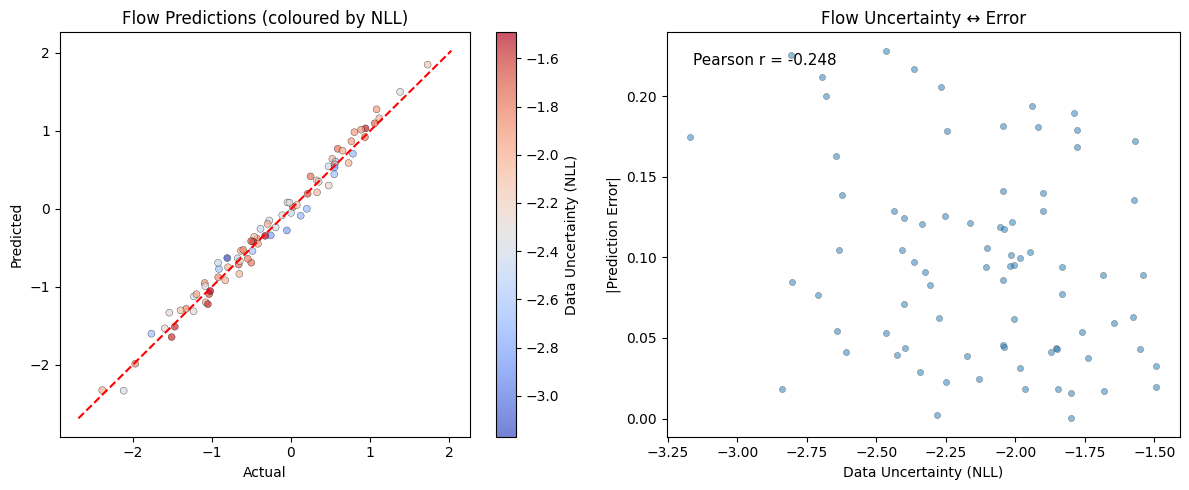

In [17]:
# Uncertainty vs error
flow_means = flow_unc["mean_predictions"].values
flow_data_unc = flow_unc["data_uncertainty"].values
flow_errors = np.abs(y_test - flow_means)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: parity plot coloured by uncertainty
sc = axes[0].scatter(
    y_test, flow_means, c=flow_data_unc, cmap="coolwarm", alpha=0.7, s=25, edgecolors="k", linewidths=0.3
)
lims = [y_test.min() - 0.3, y_test.max() + 0.3]
axes[0].plot(lims, lims, "--r")
axes[0].set(xlabel="Actual", ylabel="Predicted", title="Flow Predictions (coloured by NLL)")
plt.colorbar(sc, ax=axes[0], label="Data Uncertainty (NLL)")

# Right: uncertainty vs error
axes[1].scatter(flow_data_unc, flow_errors, alpha=0.5, s=20, edgecolors="k", linewidths=0.3)
axes[1].set(xlabel="Data Uncertainty (NLL)", ylabel="|Prediction Error|", title="Flow Uncertainty ↔ Error")
corr_f = np.corrcoef(flow_data_unc, flow_errors)[0, 1]
axes[1].annotate(f"Pearson r = {corr_f:.3f}", xy=(0.05, 0.95), xycoords="axes fraction", fontsize=11, va="top")

plt.tight_layout()
plt.show()

---

## 10  Comparing Flow Architectures

The `FlowHeadRegressor` supports seven different flow architectures:

| Flow Type | Description |
|---|---|
| `GMM` | Gaussian Mixture Model (conditional) |
| `NICE` | Non-linear Independent Components Estimation |
| `RealNVP` | Real-valued Non-Volume-Preserving flow |
| `NAF` | Neural Autoregressive Flow |
| `UNAF` | Unconstrained Neural Autoregressive Flow |
| `NSF` | Neural Spline Flow |
| `BPF` | Bernstein Polynomial Flow |

We train each one and compare R² on the same dataset.

In [18]:
X_train, X_test, y_train, y_test, y_scaler = get_regression_data()

flow_types = ["GMM", "NICE", "RealNVP", "NAF", "UNAF", "NSF", "BPF"]
results = {}

for ftype in flow_types:
    print(f"Training {ftype:8s} ... ", end="", flush=True)
    model = FlowHeadRegressor(
        flow_type=ftype,
        flow_transforms=3,
        max_epochs=60,
        lr=0.001,
        verbose=0,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test, num_samples=200)
    r2 = r2_score(y_test, y_pred)
    results[ftype] = r2
    print(f"R² = {r2:.4f}")

print("\n" + "=" * 35)
best = max(results, key=results.get)
print(f"Best flow type: {best} (R² = {results[best]:.4f})")

Training GMM      ... R² = 0.9754
Training NICE     ... R² = 0.9805
Training RealNVP  ... R² = 0.9781
Training NAF      ... R² = 0.9756
Training UNAF     ... R² = 0.9879
Training NSF      ... R² = 0.9776
Training BPF      ... R² = 0.9724

Best flow type: UNAF (R² = 0.9879)


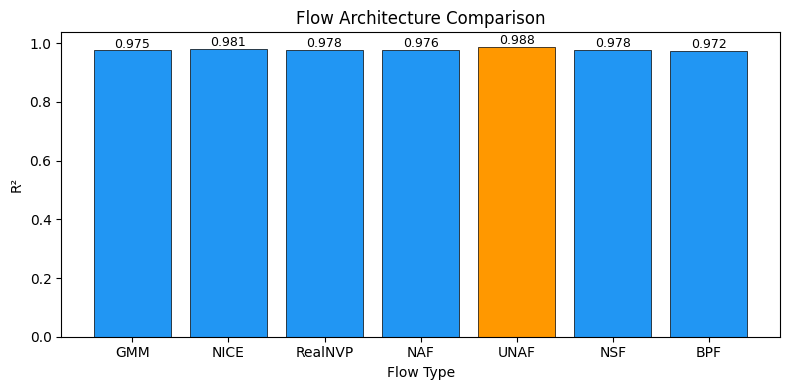

In [19]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2196F3" if ft != best else "#FF9800" for ft in flow_types]
ax.bar(results.keys(), results.values(), color=colors, edgecolor="k", linewidth=0.5)
ax.set(xlabel="Flow Type", ylabel="R²", title="Flow Architecture Comparison")
ax.axhline(0, color="gray", linewidth=0.5)
for i, (ft, v) in enumerate(results.items()):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

---

## 11  Model Serialization (Pickle)

All standalone heads support pickle serialization for easy model persistence.

In [20]:
import pickle, tempfile, os

# Save and reload the MLP regressor
with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
    pickle.dump(mlp_reg, f)
    pkl_path = f.name

with open(pkl_path, "rb") as f:
    mlp_loaded = pickle.load(f)

os.unlink(pkl_path)

# Verify predictions match
y_orig = mlp_reg.predict(X_test)
y_loaded = mlp_loaded.predict(X_test)
max_diff = np.max(np.abs(y_orig - y_loaded))
print(f"Max difference after pickle round-trip: {max_diff:.2e}")
print("✅ Serialization OK" if max_diff < 1e-5 else "❌ Mismatch!")

Max difference after pickle round-trip: 0.00e+00
✅ Serialization OK


In [21]:
# Same for FlowHeadRegressor
with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
    pickle.dump(flow_reg, f)
    pkl_path = f.name

with open(pkl_path, "rb") as f:
    flow_loaded = pickle.load(f)

os.unlink(pkl_path)

y_orig_f = flow_reg.predict(X_test, num_samples=200)
y_loaded_f = flow_loaded.predict(X_test, num_samples=200)
# Flow sampling is stochastic, so check correlation rather than exact match
corr_pkl = np.corrcoef(y_orig_f.ravel(), y_loaded_f.ravel())[0, 1]
print(f"Prediction correlation after pickle round-trip: {corr_pkl:.4f}")
print("✅ Flow serialization OK" if corr_pkl > 0.95 else "❌ Mismatch!")

Prediction correlation after pickle round-trip: 1.0000
✅ Flow serialization OK


---

## Summary

| Feature | MLPHeadRegressor | MLPHeadClassifier | FlowHeadRegressor |
|---|---|---|---|
| Task | Regression | Classification | Probabilistic Regression |
| Uncertainty | MC Dropout (epistemic) | MC Dropout (entropy) | NLL (aleatoric) |
| Multi-target | ✅ | N/A | ✅ |
| Distribution samples | — | — | `predict_flow()` |
| sklearn compatible | ✅ | ✅ | ✅ |
| Pickle serializable | ✅ | ✅ | ✅ |

### Next Steps

- Combine with NODE backbone: see `example_NODE.ipynb` for NODE + FlowHead integration
- Hyperparameter tuning: use `MotherTuner` with any standalone head as the estimator
- Feature engineering: pair with `mother.feature_generation` for molecular descriptors